In [1]:
# from lompe.data_tools import dataloader, datadownloader
from secsy.spherical import ecef_to_enu
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import lompe
import apexpy

import h5py
h=h5py.File("./lompe_eiscat/heimdall_lowel.h5","r")
print(h.keys())

# LOS ion velocity to enu coordinates transformation
vi = h['vi'][:].T
k = ecef_to_enu(h['k_norm_ecef'][:], h['lon'][:], h['lat'][:]) 
v = np.expand_dims(vi, axis=-1)   
k = np.expand_dims(k, axis=0)
v_k = v*k # velocity in enu coordinates

<KeysViewHDF5 ['Te', 'Ti', 'az', 'dTe', 'dTi', 'dne', 'dvi', 'el', 'h', 'k_norm_ecef', 'lat', 'lon', 'ne', 't_unix', 'vi']>


/Users/fasilkebede/Documents/GitHub/secsy/src/secsy/cubedsphere.py:212: RuntimeWarning: invalid value encountered in arcsin
  newlat = np.arcsin (r_[2]) / d2r


Text(0.5, 1.0, 'EISCAT measurement points')

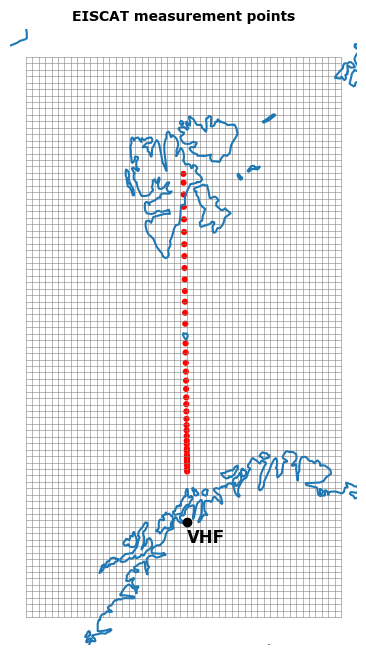

In [2]:

# cubed sphere grid parameters:
lo = h['lon'][:][24] # longitude for center of the grid
la = h['lat'][:][24] # latitude for center of the grid

position = (lo, la) # lon, lat for center of the grid
orientation =0# (-1, 2) # east, north components of vector that defines orientation of grid 

L, W, Lres, Wres = 1000e3, 1800e3, 20.e3, 20.e3 # dimensions and resolution of grid, in meters

# create grid object:
grid = lompe.cs.CSgrid(lompe.cs.CSprojection(position, orientation), L, W, Lres, Wres, R = 6481.2e3)

import secsy as cs
# Plot grid and coastlines:
fig, ax = plt.subplots(figsize = (8, 8))
# csx = cs.CSplot(ax, grid, gridtype= 'geo')
# csx.scatter(h['lon'][:], h['lat'][:])
veast, vnorth, vup = v_k[0].T
# print(veast, vnorth)

# csx.quiver(veast, vnorth, h['lon'][:], h['lat'][:])

ax.set_axis_off()
for lon, lat in grid.get_grid_boundaries():
    xi, eta = grid.projection.geo2cube(lon, lat)
    ax.plot(xi, eta, color = 'grey', linewidth = .4)

xlim, ylim = ax.get_xlim(), ax.get_ylim()
for cl in grid.projection.get_projected_coastlines():
    ax.plot(cl[0], cl[1], color = 'C0')
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)

xi_esr, eta_esr = grid.projection.geo2cube(19.13, 69.35) # svalbard radar
ax.plot(xi_esr, eta_esr, 'ko')
ax.text(xi_esr , eta_esr-0.01, 'VHF', fontsize = 12, color = 'black', fontweight = 'bold')

# xi_esr, eta_esr = grid.projection.geo2cube(16.0306, 78.1528) # svalbard radar
# ax.plot(xi_esr, eta_esr, 'ro')
# ax.text(xi_esr +.015, eta_esr, 'ESR', fontsize = 12, color = 'red', fontweight = 'bold')
ax.set_aspect('equal')
xi_e, eta_e = grid.projection.geo2cube(h['lon'][:], h['lat'][:]) # svalbard radar
# v_norm = np.linalg.norm(v_k[0], axis=1)
ax.scatter(xi_e, eta_e, c='r', s=20, edgecolors='none')
ax.set_title('EISCAT measurement points', fontsize=10, fontweight='bold')

### Adding swarm data 

In [3]:
swarm_data = pd.read_hdf('20250304_swarm.h5') 
t0 = dt.datetime(2025, 3, 4, 15, 21) # possible swarm overpasses 4:17-4:21, 13:47-13:49, 15:21-15:24   ## 12:51-12:53
t1 = dt.datetime(2025, 3, 4, 15, 24)
swarm = swarm_data[(swarm_data.Timestamp >= t0) & (swarm_data.Timestamp <= t1)]
swarm_B = np.vstack((swarm.B_e.values, swarm.B_n.values, swarm.B_u.values))
swarm_coords = np.vstack((swarm.Longitude.values, swarm.Latitude.values, swarm.Radius.values))

swarm_dat   = lompe.Data(swarm_B * 1e-9, swarm_coords,            datatype = 'space_mag_full', iweight = 1.0, error = 30e-9)


Kp = 4 # this is the input to the Hardy conductance model
T0 = t0
SH = lambda lon = grid.lon, lat = grid.lat: lompe.conductance.hardy_EUV(lon, lat, Kp, T0, 'hall')
SP = lambda lon = grid.lon, lat = grid.lat: lompe.conductance.hardy_EUV(lon, lat, Kp, T0, 'pedersen')


model = lompe.Emodel(grid, Hall_Pedersen_conductance = (SH, SP))


vs = np.squeeze(v)
k = np.squeeze(k)
# taking one time step (first instance) 
eiscat_los = lompe.Data(vs[0,:], np.vstack((h['lon'][:], h['lat'][:])), LOS = np.vstack((k[:,0],k[:,1])), datatype = 'convection')
model.add_data(eiscat_los, swarm_dat)

/Users/fasilkebede/Documents/GitHub/lompe/lompe/model/data.py:151: UserWarning: 'error' keyword not set for datatype 'convection'! Using error=50
  warnings.warn(f"'error' keyword not set for datatype '{datatype}'! Using error={error}", UserWarning)
/Users/fasilkebede/Documents/GitHub/lompe/lompe/model/data.py:155: UserWarning: 'iweight' keyword not set for datatype 'convection'! Using iweight=1.0
  warnings.warn(f"'iweight' keyword not set for datatype '{datatype}'! Using iweight={iweight}", UserWarning)


In [ ]:
model.run_inversion(l1 = 1, l2 = 10); # with default regularization parameters

/Users/fasilkebede/Documents/GitHub/secsy/src/secsy/cubedsphere.py:212: RuntimeWarning: invalid value encountered in arcsin
  newlat = np.arcsin (r_[2]) / d2r


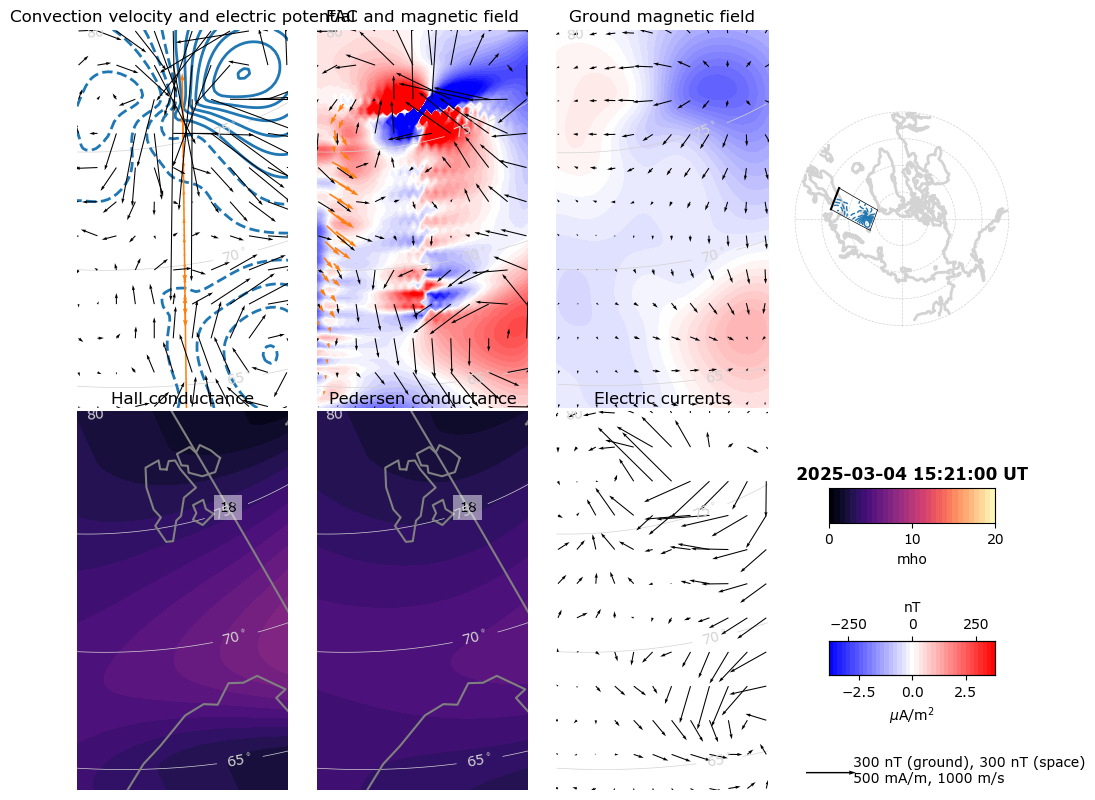

In [5]:
apex = apexpy.Apex(T0, refh = 110)
savestr = f'./lompeplot_eiscat_event_{str(t0)}.png' 
savekw = {'fname': savestr}
# finally, plot (plot is saved as specified path):
fig = lompe.lompeplot(model, include_data = True, time = T0, apex = apex, savekw=savekw)